In [1]:
import pycbc.waveform
from matplotlib import pyplot as plt
import lal
from pyseobnr.generate_waveform import GenerateWaveform

/work/yifanwang/ecc/env913ecc/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:
p = {'mass1':10,'mass2':10}
p.update({
        "approximant": "SEOBNRv5EHM", # I call it "SEOBNRv5E" in PyCBC 
        "ModeArray": [(2,2)],      # only consider (2,2) mode
        #"postadiabatic": False ,   # turn off postadiabatic correction, 
                                   # default is False in SEOBNRv5EHM
        #"h_0": 1.0,                # initial time step in the integration of the ODEs. 
                                    # Default Value is 1.0
        "lmax_nyquist": 1          # maximum L to be checked against Nyquist frequency
        })
waveform = GenerateWaveform(p)
eob, _ = waveform.generate_td_polarizations_conditioned_1()

In [3]:
float(eob.epoch)

-5.974121094

In [4]:
kwds = {'mass1':10,
        'mass2':10,
        'rel_anomaly':0,}
        
hp, _ = pycbc.waveform.get_fd_waveform(delta_f=1/32,
                                        f_lower=20,
                                        approximant = 'SEOBNRv5E',
                                        **kwds)

In [5]:
hp._epoch

LIGOTimeGPS(-31, -960937500)

In [6]:
hp.eob_template_duration

5.974121094

In [52]:
ht, _ = pycbc.waveform.get_td_waveform(delta_t=1/2048,
                                        f_lower=20,
                                        approximant='SEOBNRv5E_tdtaper',
                                        **kwds)

In [53]:
ht.start_time

LIGOTimeGPS(-5, -974121094)

In [56]:
htlal = ht.lal()

In [58]:
htlal.epoch

LIGOTimeGPS(-5, -974121094)

In [50]:
deltaF = 1/32
deltaT = 1/2048
chirplen = int(1.0 / (deltaF * deltaT))

In [60]:
chirplen, htlal.data.length

(65536, 12315)

In [61]:
lal.ResizeREAL8TimeSeries(htlal, htlal.data.length - chirplen, chirplen)

<Swig Object of type 'tagREAL8TimeSeries *' at 0x1523b1ac9930>

In [62]:
htlal.data.length

65536

In [63]:
htlal.epoch

LIGOTimeGPS(-31, -960937500)

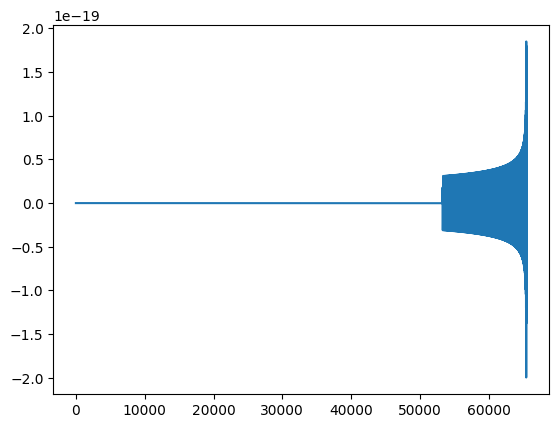

In [64]:
plt.plot(htlal.data.data)